In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from diffusers import UNet2DModel

sys.path.append("../")

from oxels.analytical_benchmark import TwoShapes
from oxels.datasets import AnalyticDataset
from oxels.losses import original_loss
from oxels.visualization.plot_channels import plot_channels

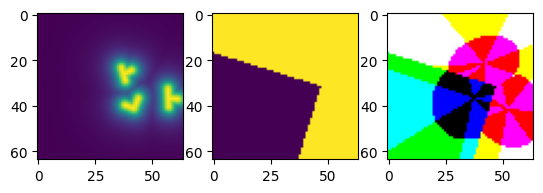

In [2]:
cs = [np.array([-0.25,-0.25]), np.array([0.25,0.25]), np.array([-0.25,0.25])]
as_ = np.random.random(3)*2*np.pi
Ms = np.array([[[np.cos(a), np.sin(a)],[-np.sin(a), np.cos(a)]] for a in as_])
Ms += np.random.normal(0,0.2,Ms.shape)
types = [1,1,0]
#plt.imshow(get_pattern(cs, Ms, types, np.array([0.0,0]), 1.5*np.array([[0.8,-0.6],[0.6,0.8]])))

ts = TwoShapes()
a = 0.3
plt.subplot(131)
params = (cs, Ms, types, np.array([0.5,0]), np.array([[np.cos(a), np.sin(a)],[-np.sin(a), np.cos(a)]]))
plt.imshow(ts.get_image(*params))
plt.subplot(132)
local_Rs, local_As, local_types = ts.get_polar_coordinates(*params)
plt.imshow(local_types)
plt.subplot(133)

oxels = ts.get_encoded_coordinates(*params, n_bits_dist=3, n_bits_angle=3, max_dist=1)
#plt.imshow(oxels[:,:,1:4])
plt.imshow(oxels[:,:,[0,1,-1]])

(64, 64, 1)


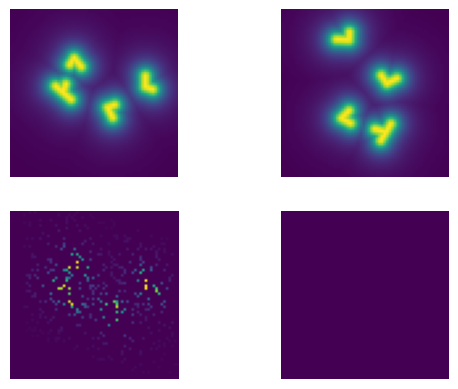

In [3]:
   
dataset = AnalyticDataset(1024, lambda x: x, 64, 64)
view1, view2, indices, flags, mask1, mask2 = dataset._get_data("")
plt.subplot(221)
plt.imshow(view1)
plt.axis("off")
plt.subplot(222)
plt.imshow(view2)
plt.axis("off")
plt.subplot(223)
plt.imshow((view2.reshape((-1,1))[indices]*flags[:,None]).reshape(view2.shape))
plt.axis("off")
plt.subplot(224)
plt.imshow(mask1.reshape(view1.shape[:2]))
plt.axis("off")
print(view1.shape)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
batch_size = 8

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    num_workers=len(os.sched_getaffinity(0)),
    pin_memory=True,
    shuffle=True,
    drop_last=True
)

In [6]:
# import wandb

# # Start a new wandb run to track this script.
# run = wandb.init(
#     entity="kl_divergence-rensselaer-polytechnic-institute",
#     project="oxels",
# )

In [7]:
network = UNet2DModel(
    sample_size=(64, 64),
    in_channels=1, 
    out_channels=15,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),
    time_embedding_dim=1,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "AttnDownBlock2D"
    ),
    up_block_types=(
        "AttnUpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

In [8]:
dummy_t = torch.tensor([0]).to(device)

In [11]:
view1, view2, permutation, flags, mask1, mask2 = next(iter(loader))

In [12]:
%%time
with torch.no_grad():
    oxels1 = network(view1.to(device), dummy_t)["sample"]
    oxels2 = network(view2.to(device), dummy_t)["sample"]
    print(original_loss(oxels1, oxels2, permutation.to(device), flags.to(device), mask1.to(device), mask2.to(device)))

tensor(0.2047, device='cuda:0')
CPU times: user 10.5 ms, sys: 3.09 ms, total: 13.6 ms
Wall time: 13.1 ms


In [ ]:
EPOCHS = 1000
SAVE_EVERY = 25
LEARNING_RATE = 9e-5
LOG_EVERY = 5

optimizer = torch.optim.Adam(network.parameters(), lr=LEARNING_RATE)


scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

for epoch in range(EPOCHS):
    network.train()
    total_loss = 0.0

    for step, (view1, view2, permutation, flags, mask1, mask2) in enumerate(loader):
        view1 = view1.to(device)
        view2 = view2.to(device)
        permutation = permutation.to(device)
        flags = flags.to(device)
        mask1 = mask1.to(device)
        mask2 = mask2.to(device)

        optimizer.zero_grad()
        oxels1 = network(view1, dummy_t)["sample"]
        oxels2 = network(view2, dummy_t)["sample"]

        loss = original_loss(oxels1, oxels2, permutation, flags, mask1, mask2)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # if step % LOG_EVERY == 0:
        #     run.log(data={"loss": loss})
            
    scheduler.step()

    avg_loss = total_loss / len(loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.3f}, LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save model checkpoint
    if epoch % SAVE_EVERY == 0:
        torch.save(network.state_dict(), f"../checkpoints/checkpoint_epoch_{epoch+1}.pth")

Epoch 1/1000, Loss: 0.052, LR: 9.00e-05


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x737806bb27b0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 737942f4c8d0, raw_cell="f = plot_channels(oxels2[0])" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/space/oxels/notebooks/analytic_example.ipynb#X15sZmlsZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

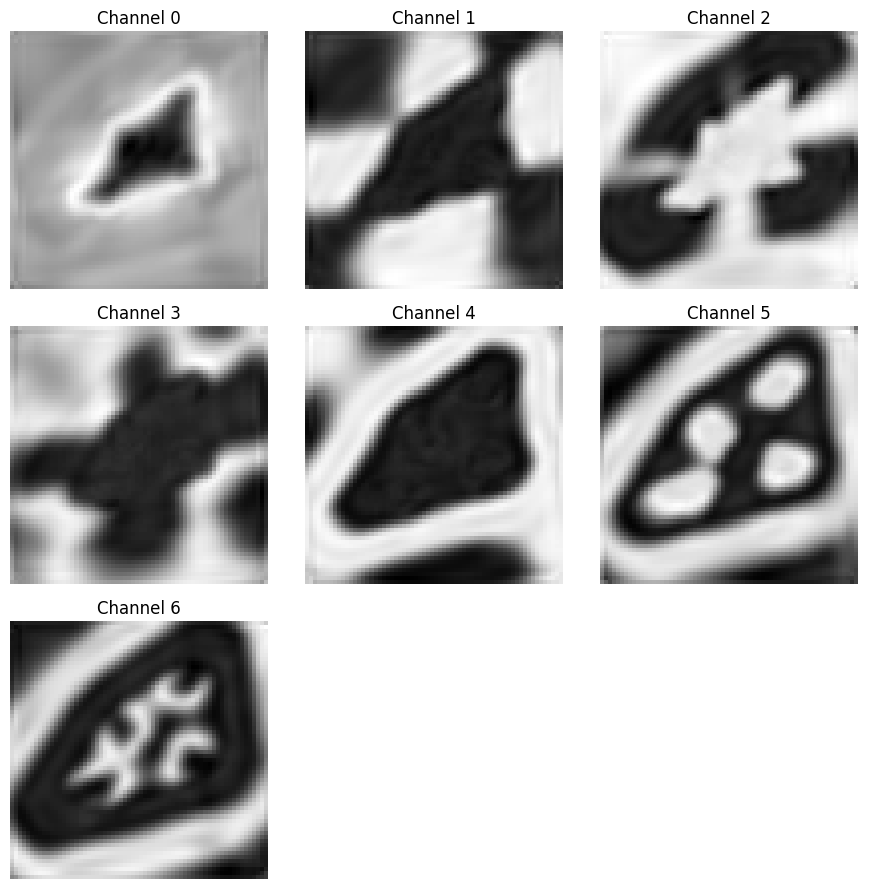

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x737806bb27b0>> (for post_run_cell), with arguments args (<ExecutionResult object at 737942f821d0, execution_count=16 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 737942f4c8d0, raw_cell="f = plot_channels(oxels2[0])" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/space/oxels/notebooks/analytic_example.ipynb#X15sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [16]:
f = plot_channels(oxels2[0])